In [1]:
import pandas as pd
df_index = pd.read_csv("indexing/index_20220213_curated.csv",index_col="full")

df_mpra3 = pd.read_csv("indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv").drop_duplicates("enhancer_id")
df_mpra3[["enhancer_id","Type","RSID","Contributor","nearest_gene"]].to_csv("indexing/RSID_Contributor_nearestGene.csv",index=False)
df_mpra3 = pd.read_csv("indexing/RSID_Contributor_nearestGene.csv",index_col="enhancer_id")

df_index = pd.merge(df_index, df_mpra3,left_index=True,right_index=True,how="left")
df_index.to_csv("indexing/index_20240103_curated.csv")

In [ ]:
#Annotate Minor Alleless
import pandas as pd
df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_20240417.csv',index_col=0)
rare = df[(df['EUR']<=0.01) | (df['EUR']>=0.99)]
df.loc[df[df['EUR']>=0.5].index,"REFALT_Flip"]="True"
df.loc[df[df['EUR']<0.5].index,"REFALT_Flip"]="False"
df.loc[df[df['Contributor']=="Bertram"].index,"REFALT_Flip"]="False"
df.to_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_20240604.csv')

In [6]:
import pandas as pd
df_original = pd.read_csv('/media/zihengc/Depository/T720231129/mpra/MPRA_design/motifs_overlap_snps/all_motifs_new.csv' )
df_original = df_original[df_original["is_query_snp"]==1]
df_result = pd.read_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/allele_differences/Brain/20231128_comparative_BrainR1R2merged_allele.csv',index_col=0)
df_result

# Filter rows where index starts with 'alt' and split the index to extract rsID
df_alt = df_result[df_result.index.str.split(':').str[0] == "alt"]
rsid_list = df_alt.index.str.split(':').str[1]

# Filter rows in df_original where 'rsID' is in rsid_list and remove duplicates
df_matched = df_original[df_original["rsID"].isin(rsid_list)].drop_duplicates(subset=["rsID"])

# Create a new DataFrame with MPRA_Seq_ID and rsID
df_merged = pd.DataFrame()
df_merged["MPRA_Seq_ID"] = df_alt.index
df_merged["rsID"] = rsid_list 

# Merge df_merged with df_matched on 'rsID'
df_merged = pd.merge(df_merged, df_matched, on="rsID", how="left")

# Read the contributor DataFrame
df_contributor = pd.read_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/indexing/RSID_Contributor_nearestGene.csv')

# Standardize column name in df_contributor for consistency
df_contributor.rename(columns={"enhancer_id": "MPRA_Seq_ID"}, inplace=True)

# Merge df_merged with df_contributor on 'MPRA_Seq_ID'
df_final = pd.merge(df_merged, df_contributor, how="left", on="MPRA_Seq_ID").set_index("MPRA_Seq_ID")

# Identify columns from df_contributor to be moved to the front, excluding "MPRA_Seq_ID"
contributor_columns = df_contributor.columns.drop("MPRA_Seq_ID").tolist()

# Identify remaining columns in df_final not in contributor_columns
other_columns = [col for col in df_final.columns if col not in contributor_columns]

# Reorder the columns in df_final
df_final = df_final[contributor_columns + other_columns].sort_index()

# Save the final DataFrame to a CSV file
df_final.to_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_20231203.csv')

# Display the final DataFrame
df_final

snp_list = []
for i in df_final.index:
    if i.split(':')[4]:
        snp_list.append(i.split(':')[4])
    else:
        snp_list.append('NA')

df_final["snp_original"] = snp_list
df_final['snp_original_haploreghg38'] = df_final["snp_original"].astype(float) == df_final["pos_hg38"]
df_final.to_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_20231203.csv')
df_final['snp_original_haploreghg38']

MPRA_Seq_ID
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676       False
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950       False
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199           False
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308        False
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847           False
                                                                             ...  
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051     True
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854      True
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195        False
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583        False
alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:61522574:61522824:61522636       False
Name: snp_original_haploreghg38, Length: 855, dtype: bool

In [28]:
# Replace NaN in 'pos_hg38' based on 'Contributor' and the index
df_final['pos_hg38'] = df_final.apply(
    lambda row: row['pos_hg38'] if row['Contributor'] == "Bertram" or pd.notna(row['pos_hg38'])
    else row.name.split(':')[4] if len(row.name.split(':')) > 4 
    else row['pos_hg38'],
    axis=1
)


df_final

In [7]:
#Badoi's snps are in hg38
df_badoi = pd.read_csv('/media/zihengc/Depository/T720231129/mpra/MPRA_design/BaDoi/099polyfun_for_overlap_peaks.csv',index_col=0)
df_final[df_final['RSID'].isin(df_badoi['SNP'])]["RSID"]

MPRA_Seq_ID
alt:rs10030602:PEAKCENTER:chr4:112086886:G:A:112086668:112087168:112086918     rs10030602
alt:rs11218343:SNPCENTER:chr11:121564878:C:T:121564765:1215644991:121564878    rs11218343
alt:rs11638244:PEAKCENTER:chr15:58614952:A:T:58614610:58615110:58614860        rs11638244
alt:rs11638244:SNPCENTER:chr15:58614952:A:T:58614610:58615110:58614860         rs11638244
alt:rs1968456:PEAKCENTER:chr19:1063080:G:C:1062752:1063310:1063075              rs1968456
alt:rs28399594:PEAKCENTER:chr19:44806715:G:T:44806518:44807018:44806768        rs28399594
Name: RSID, dtype: object

In [8]:
# List to store indices where conditions are met
indices_to_add = []

def process_row(row):
    if row['Contributor'] == "Bertram" or pd.notna(row['pos_hg38']):
        return row['pos_hg38']
    elif row['Contributor'] != "Pfenning":
        return row.name.split(':')[4] if len(row.name.split(':')) > 4 else row['pos_hg38']
    else:  # Handling the "Pfenning" case
        if row['RSID'] in df_final[df_final['RSID'].isin(df_badoi['SNP'])]['RSID'].values:
            return row.name.split(':')[4] if len(row.name.split(':')) > 4 else row['pos_hg38']
        else:
            if len(row.name.split(':')) > 4:
                indices_to_add.append(row.name)  # Add the index to the list
            return row['pos_hg38']

df_final['pos_hg38'] = df_final.apply(process_row, axis=1)

#Bertram and Pfenning hg19
df_tmp = df_final[df_final['pos_hg38'].isna()]
print("hg19")
for index in df_tmp.index:
    parts = index.split(':')
    if len(parts) >= 5:  # Ensure there are enough parts in the index
        fourth_part = parts[3]
        fifth_part = str(int(parts[4]))
        formatted_string = f"{fourth_part}:{parts[4]}-{fifth_part}"
        print(formatted_string)
    else:
        "error"


hg19
chr19:42927676-42927676
chr16:89598950-89598950
chr16:2255199-2255199
chr8:41519308-41519308
chr19:2720847-2720847
chr10:73472315-73472315
chr3:182968758-182968758
chr19:49962324-49962324
chr10:72298745-72298745
chr17:4098227-4098227
chr6:82460558-82460558
chr11:85828548-85828548
chr6:32572576-32572576
chr6:32576394-32576394


# in hg38
chr19:42423524-42423524
chr16:89532542-89532542
chr16:2205198-2205198
chr8:41661790-41661790
chr19:2720849-2720849
chr10:71712558-71712558
chr3:183250970-183250970
chr19:49459067-49459067
chr10:70538989-70538989
chr17:4194932-4194932
chr6:81750841-81750841
chr11:86117506-86117506
chr6:32604799-32604799
chr6:32608617-32608617

In [23]:
#get liftover results in hg38
pos_hg38 = [
42423524,
89532542,
2205198,
41661790,
2720849,
71712558,
183250970,
49459067,
70538989,
4194932,
81750841,
86117506,
32604799,
32608617,
]
df_tmp["pos_hg38"] = pos_hg38
####Replace the df_final nan by df_tmp
for idx in df_tmp.index:
    if idx in df_final.index:
        df_final.loc[idx, 'pos_hg38'] = df_tmp.loc[idx, 'pos_hg38']

# Replace NaN in 'chr' with the number
df_final['chr'] = df_final.apply(
    lambda row: row['chr'] if pd.notna(row['chr']) 
    else row.name.split(':')[3][3:] if len(row.name.split(':')) > 3 
    else row['chr'], 
    axis=1
)
df_final["SNP_ID"] = ["SNP_" + str(i) for i in range(len(df_final))]
df_final.to_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv')

/tmp/ipykernel_28868/693431136.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp["pos_hg38"] = pos_hg38


In [27]:
#Save SNPs for Zunpeng
df_final[["SNP_ID","chr","pos_hg38"]].to_csv('/media/zihengc/Depository/T720231129/mpra3_lib_analysis/indexing/SNP_all_hg38_pos_20240104.csv',index=False)

## Find overlap peaks

In [34]:
import pandas as pd
import os
import gzip
from collections import defaultdict

# Load the final DataFrame
df_peak = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_annotated_index_20240902_curated_annotated.csv', index_col=0)

def is_within_peak(chrom, pos, peak_dict):
    chrom = str(chrom)
    pos = int(pos)
    if chrom in peak_dict:
        chrom_peaks = peak_dict[chrom]
        # Filter to get rows where 'pos' is within peak ranges
        overlaps = chrom_peaks[(chrom_peaks['start'] <= pos) & (chrom_peaks['end'] >= pos)]
        # Return the count of overlapping peaks
        return len(overlaps)
    return 0


directory = '/media/zihengc/T7/atac/jaccard_index/merged_peaks_200bp_20240907/'
#'/media/zihengc/T7/atac/all_open_chromatin_peaks/20240903_mpra_annotation'

for filename in os.listdir(directory):
    column_name=None
    if not os.path.isdir(directory+filename):#filename.endswith(".txt") or filename.endswith(".bed"):

        file_path = os.path.join(directory, filename)
        if filename.endswith(".gz"):
            with gzip.open(file_path, 'rt') as f:
                peaks_df = pd.read_csv(f, sep='\t', header=0, usecols=[0, 1, 2])
                
        else:
            peaks_df = pd.read_csv(file_path, sep='\t', header=None, usecols=[0, 1, 2])
            
        peaks_df.columns = ['chrom', 'start', 'end']
        peaks_df['chrom'] = peaks_df['chrom'].str.replace('chr', '', regex=False)
        peak_dict = {k: v for k, v in peaks_df.groupby('chrom')}
        column_name = filename#if filename.endswith(".txt"): #filename.endswith(".annotation.txt.gz") or filename.endswith(".optimal_peak.narrowPeak.gz"):
        #    column_name = filename[:-4] #column_name = '.'.join(filename.split('.')[:-4])
        #elif filename.endswith(".bed"):
        #    column_name = filename[:-4]
         #else: 
            
        df_peak[column_name] = df_peak.apply(lambda row: is_within_peak(row['chr_number'], row['pos_hg38'], peak_dict), axis=1)
        print(filename,column_name)
df_gc = pd.read_csv( '/media/zihengc/T7/mpra3_lib_analysis/indexing/enhancer_GC_content.csv' ,index_col=0)
df_peak = pd.merge(df_peak,df_gc,left_index=True,right_index=True)
df_peak.to_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_20240903.csv')

##############################################annotate TSS#################################################
import pandas as pd
import gzip

# Function to read GTF file and extract TSS information
def read_gtf(path):
    # Define the columns based on the GTF format
    col_names = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attributes']
    # Use gzip.open to read the gzipped GTF file
    with gzip.open(path, 'rt') as file:
        df = pd.read_csv(file, delimiter='\t', comment='#', names=col_names)
    # Filter for genes and calculate TSS based on strand
    tss_data = df[df['feature'] == 'gene'].copy()
    tss_data['tss'] = tss_data.apply(lambda x: x['start'] if x['strand'] == '+' else x['end'], axis=1)
    return tss_data[['seqname', 'tss', 'strand']]

# Function to read BED file
def read_bed(path):
    # BED columns typically include chromosome, start, end, (name, score, strand are optional)
    col_names = ['chr', 'start', 'end']
    return pd.read_csv(path, delimiter='\t', names=col_names)

# Load data
gtf_path = '/media/zihengc/T7/resources/Gencode_genome_annotation/gencode.v45.annotation.gtf.gz' 
bed_path = '/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.bed'

gtf_data = read_gtf(gtf_path)
snp_data = read_bed(bed_path)

# Calculate distances
def calculate_distance(snp_row):
    # Filter relevant TSS data for the chromosome
    chr_tss_data = gtf_data[gtf_data['seqname'] == snp_row['chr']]
    # Calculate distances to all TSS on the chromosome
    distances = chr_tss_data['tss'] - snp_row['start']
    # Get the closest distance, preserving the sign to indicate direction relative to TSS
    closest_distance = distances.abs().min()
    return distances.loc[distances.abs().idxmin()]

# Apply function to SNP data
snp_data['distance_to_tss'] = snp_data.apply(calculate_distance, axis=1)

# Display results
print(snp_data)

df_peak = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_20240903.csv',index_col=0)  # replace with your DataFrame
df_peak['distance_to_tss']=snp_data['distance_to_tss'].tolist()
df_peak.to_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv')

Encode_Monocyte_DHS_hg38.narrowPeak Encode_Monocyte_DHS_hg38.narrowPeak
Gosselin_Microglia_ATAC_hg38.idr.optimal_peak.narrowPeak Gosselin_Microglia_ATAC_hg38.idr.optimal_peak.narrowPeak
HMC3.idr.optimal_peak.narrowPeak HMC3.idr.optimal_peak.narrowPeak
Kosoy_Microglia_OCRs_hg38.bed Kosoy_Microglia_OCRs_hg38.bed
M2_IFNG.idr.optimal_peak.narrowPeak M2_IFNG.idr.optimal_peak.narrowPeak
M2_NAIVE.idr.optimal_peak.narrowPeak M2_NAIVE.idr.optimal_peak.narrowPeak
mono_hg38.bed mono_hg38.bed
THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak
THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak
THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak
THP1_monocytes.idr.optimal_peak.narrowPeak THP1_monocytes.idr.optimal_peak.narrowPeak
THP1_Naive_4hrs.idr.optimal_peak.narrowPeak THP1_Naive_4hrs.idr.optimal_peak.narrowPeak
TLR4_IFNG.idr.optimal_peak.narrowPeak TLR4_IFNG.idr.optimal_peak.narrowPeak


In [10]:
df_peak = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv',index_col=0)  # replace with your DataFrame
df_peak = df_peak.drop_duplicates('RSID')
df_peakonly = df_peak.iloc[:, 76:].applymap(lambda x: 1 if x != 0 else 0).drop(['IFNB4_vs_Naive_IHW', 'IFNG4_vs_Naive_IHW', 'LPSIFNG4_vs_Naive_IHW','GC_content','distance_to_tss'],axis=1)

# Perform K-means clustering on rows
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_peakonly)
df_peakonly['Cluster'] = clusters
df_peakonly = df_peakonly.sort_values('Cluster')
clusters_new = df_peakonly['Cluster']
df_peakonly = df_peakonly.drop('Cluster', axis=1)

# Perform K-means clustering on columns
kmeans2 = KMeans(n_clusters=4, random_state=42)
clusters2 = kmeans2.fit_predict(df_peakonly.T)
# Add the cluster labels to the DataFrame as a new row
df_peakonly.loc['Cluster2',:] = clusters2
df_peakonly = df_peakonly.sort_values('Cluster2', axis=1)
clusters2_new = df_peakonly.loc['Cluster2',:]

/tmp/ipykernel_121061/3142538108.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_peakonly = df_peak.iloc[:, 76:].applymap(lambda x: 1 if x != 0 else 0).drop(['IFNB4_vs_Naive_IHW', 'IFNG4_vs_Naive_IHW', 'LPSIFNG4_vs_Naive_IHW','GC_content','distance_to_tss'],axis=1)


/tmp/ipykernel_75823/2313979880.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


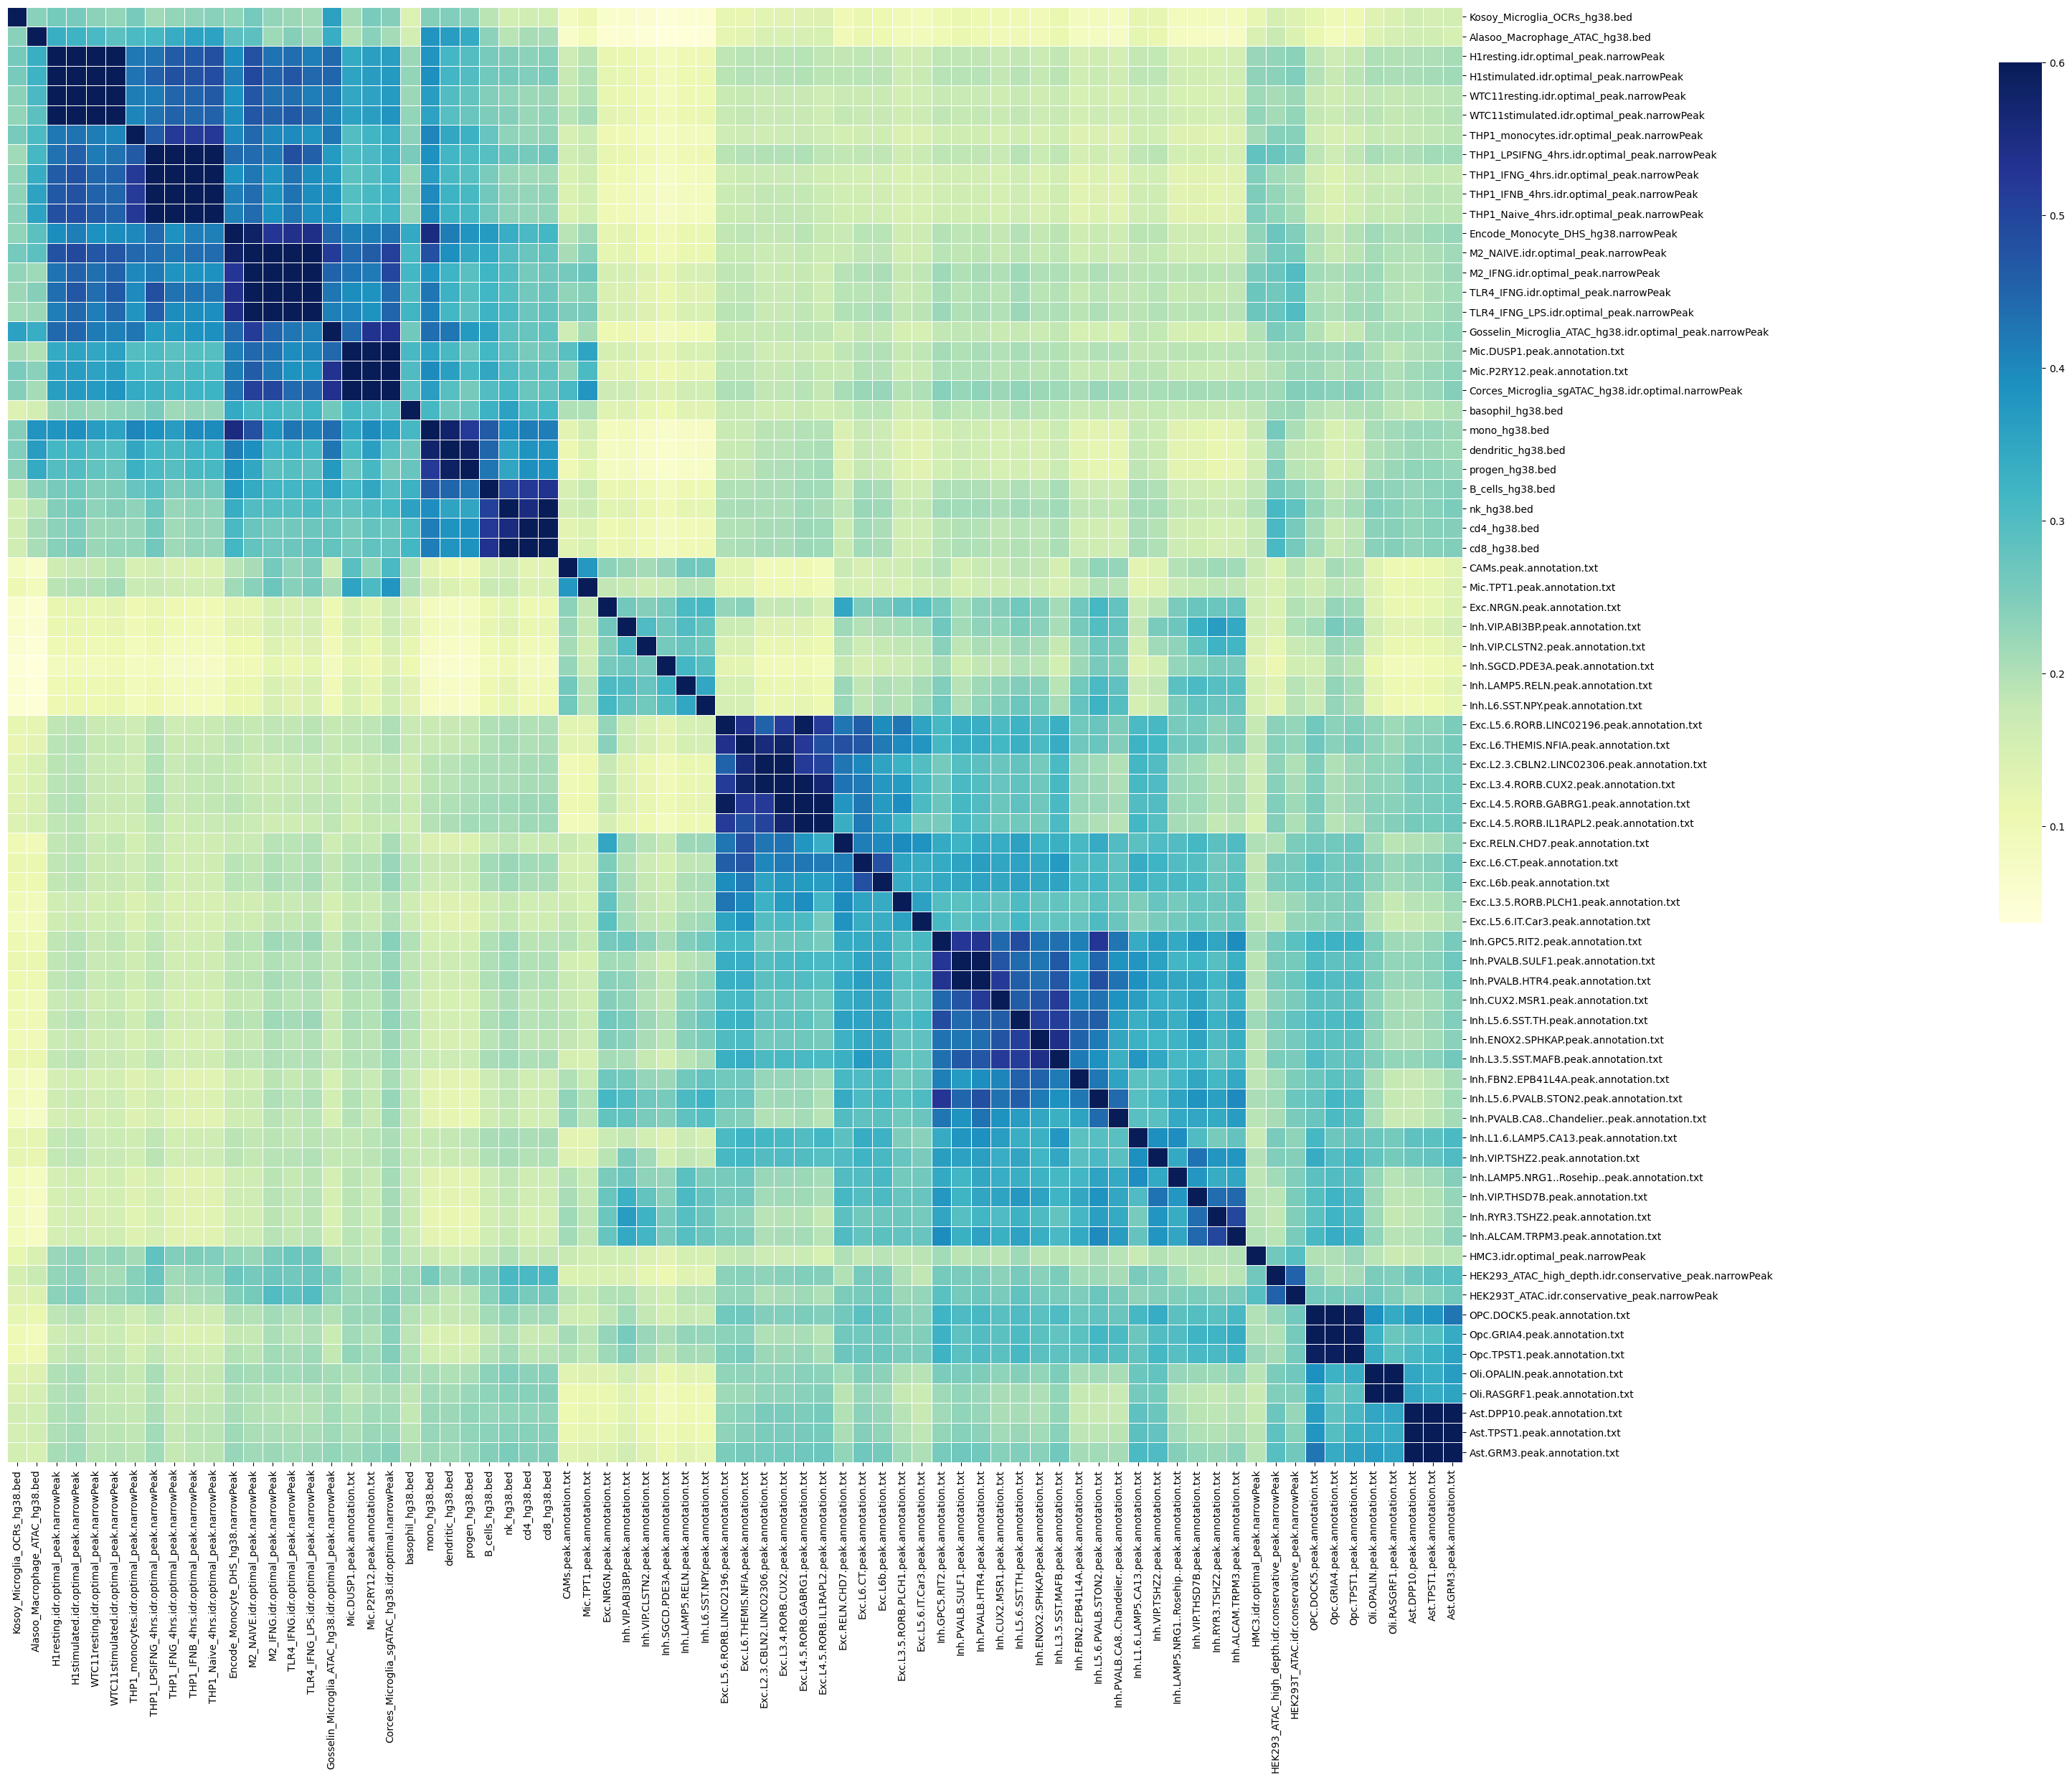

Row order after clustering: [3, 67, 63, 64, 65, 66, 10, 9, 8, 7, 11, 0, 5, 4, 12, 13, 1, 16, 62, 68, 72, 6, 71, 73, 70, 15, 23, 28, 14, 32, 18, 51, 52, 50, 43, 55, 22, 24, 27, 46, 39, 41, 60, 19, 20, 31, 49, 35, 42, 45, 34, 40, 29, 37, 36, 26, 44, 25, 38, 30, 53, 48, 54, 2, 47, 69, 61, 56, 58, 57, 59, 33, 17, 21]
Column order after clustering: [3, 67, 63, 64, 65, 66, 10, 9, 8, 7, 11, 0, 5, 4, 12, 13, 1, 16, 62, 68, 72, 6, 71, 73, 70, 15, 23, 28, 14, 32, 18, 51, 52, 50, 43, 55, 22, 24, 27, 46, 39, 41, 60, 19, 20, 31, 49, 35, 42, 45, 34, 40, 29, 37, 36, 26, 44, 25, 38, 30, 53, 48, 54, 2, 47, 69, 61, 56, 58, 57, 59, 33, 17, 21]


In [14]:
df_peak = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv',index_col=0)  # replace with your DataFrame
df_peak = df_peak.drop_duplicates('RSID')
df_peakonly = df_peak.iloc[:, 76:].applymap(lambda x: 1 if x != 0 else 0).drop(['GC_content','distance_to_tss'],axis=1)


/tmp/ipykernel_75823/2436111228.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_peakonly = df_peak.iloc[:, 76:].applymap(lambda x: 1 if x != 0 else 0).drop(['GC_content','distance_to_tss'],axis=1)


,Kosoy_Microglia_OCRs_hg38.bed,Alasoo_Macrophage_ATAC_hg38.bed,H1resting.idr.optimal_peak.narrowPeak,H1stimulated.idr.optimal_peak.narrowPeak,WTC11resting.idr.optimal_peak.narrowPeak,WTC11stimulated.idr.optimal_peak.narrowPeak,THP1_monocytes.idr.optimal_peak.narrowPeak,THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak,THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak,THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak,...,HEK293_ATAC_high_depth.idr.conservative_peak.narrowPeak,HEK293T_ATAC.idr.conservative_peak.narrowPeak,OPC.DOCK5.peak.annotation.txt,Opc.GRIA4.peak.annotation.txt,Opc.TPST1.peak.annotation.txt,Oli.OPALIN.peak.annotation.txt,Oli.RASGRF1.peak.annotation.txt,Ast.DPP10.peak.annotation.txt,Ast.TPST1.peak.annotation.txt,Ast.GRM3.peak.annotation.txt
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,1,1,1
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,1,1,1,1,1
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,1,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_195221/684809797.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


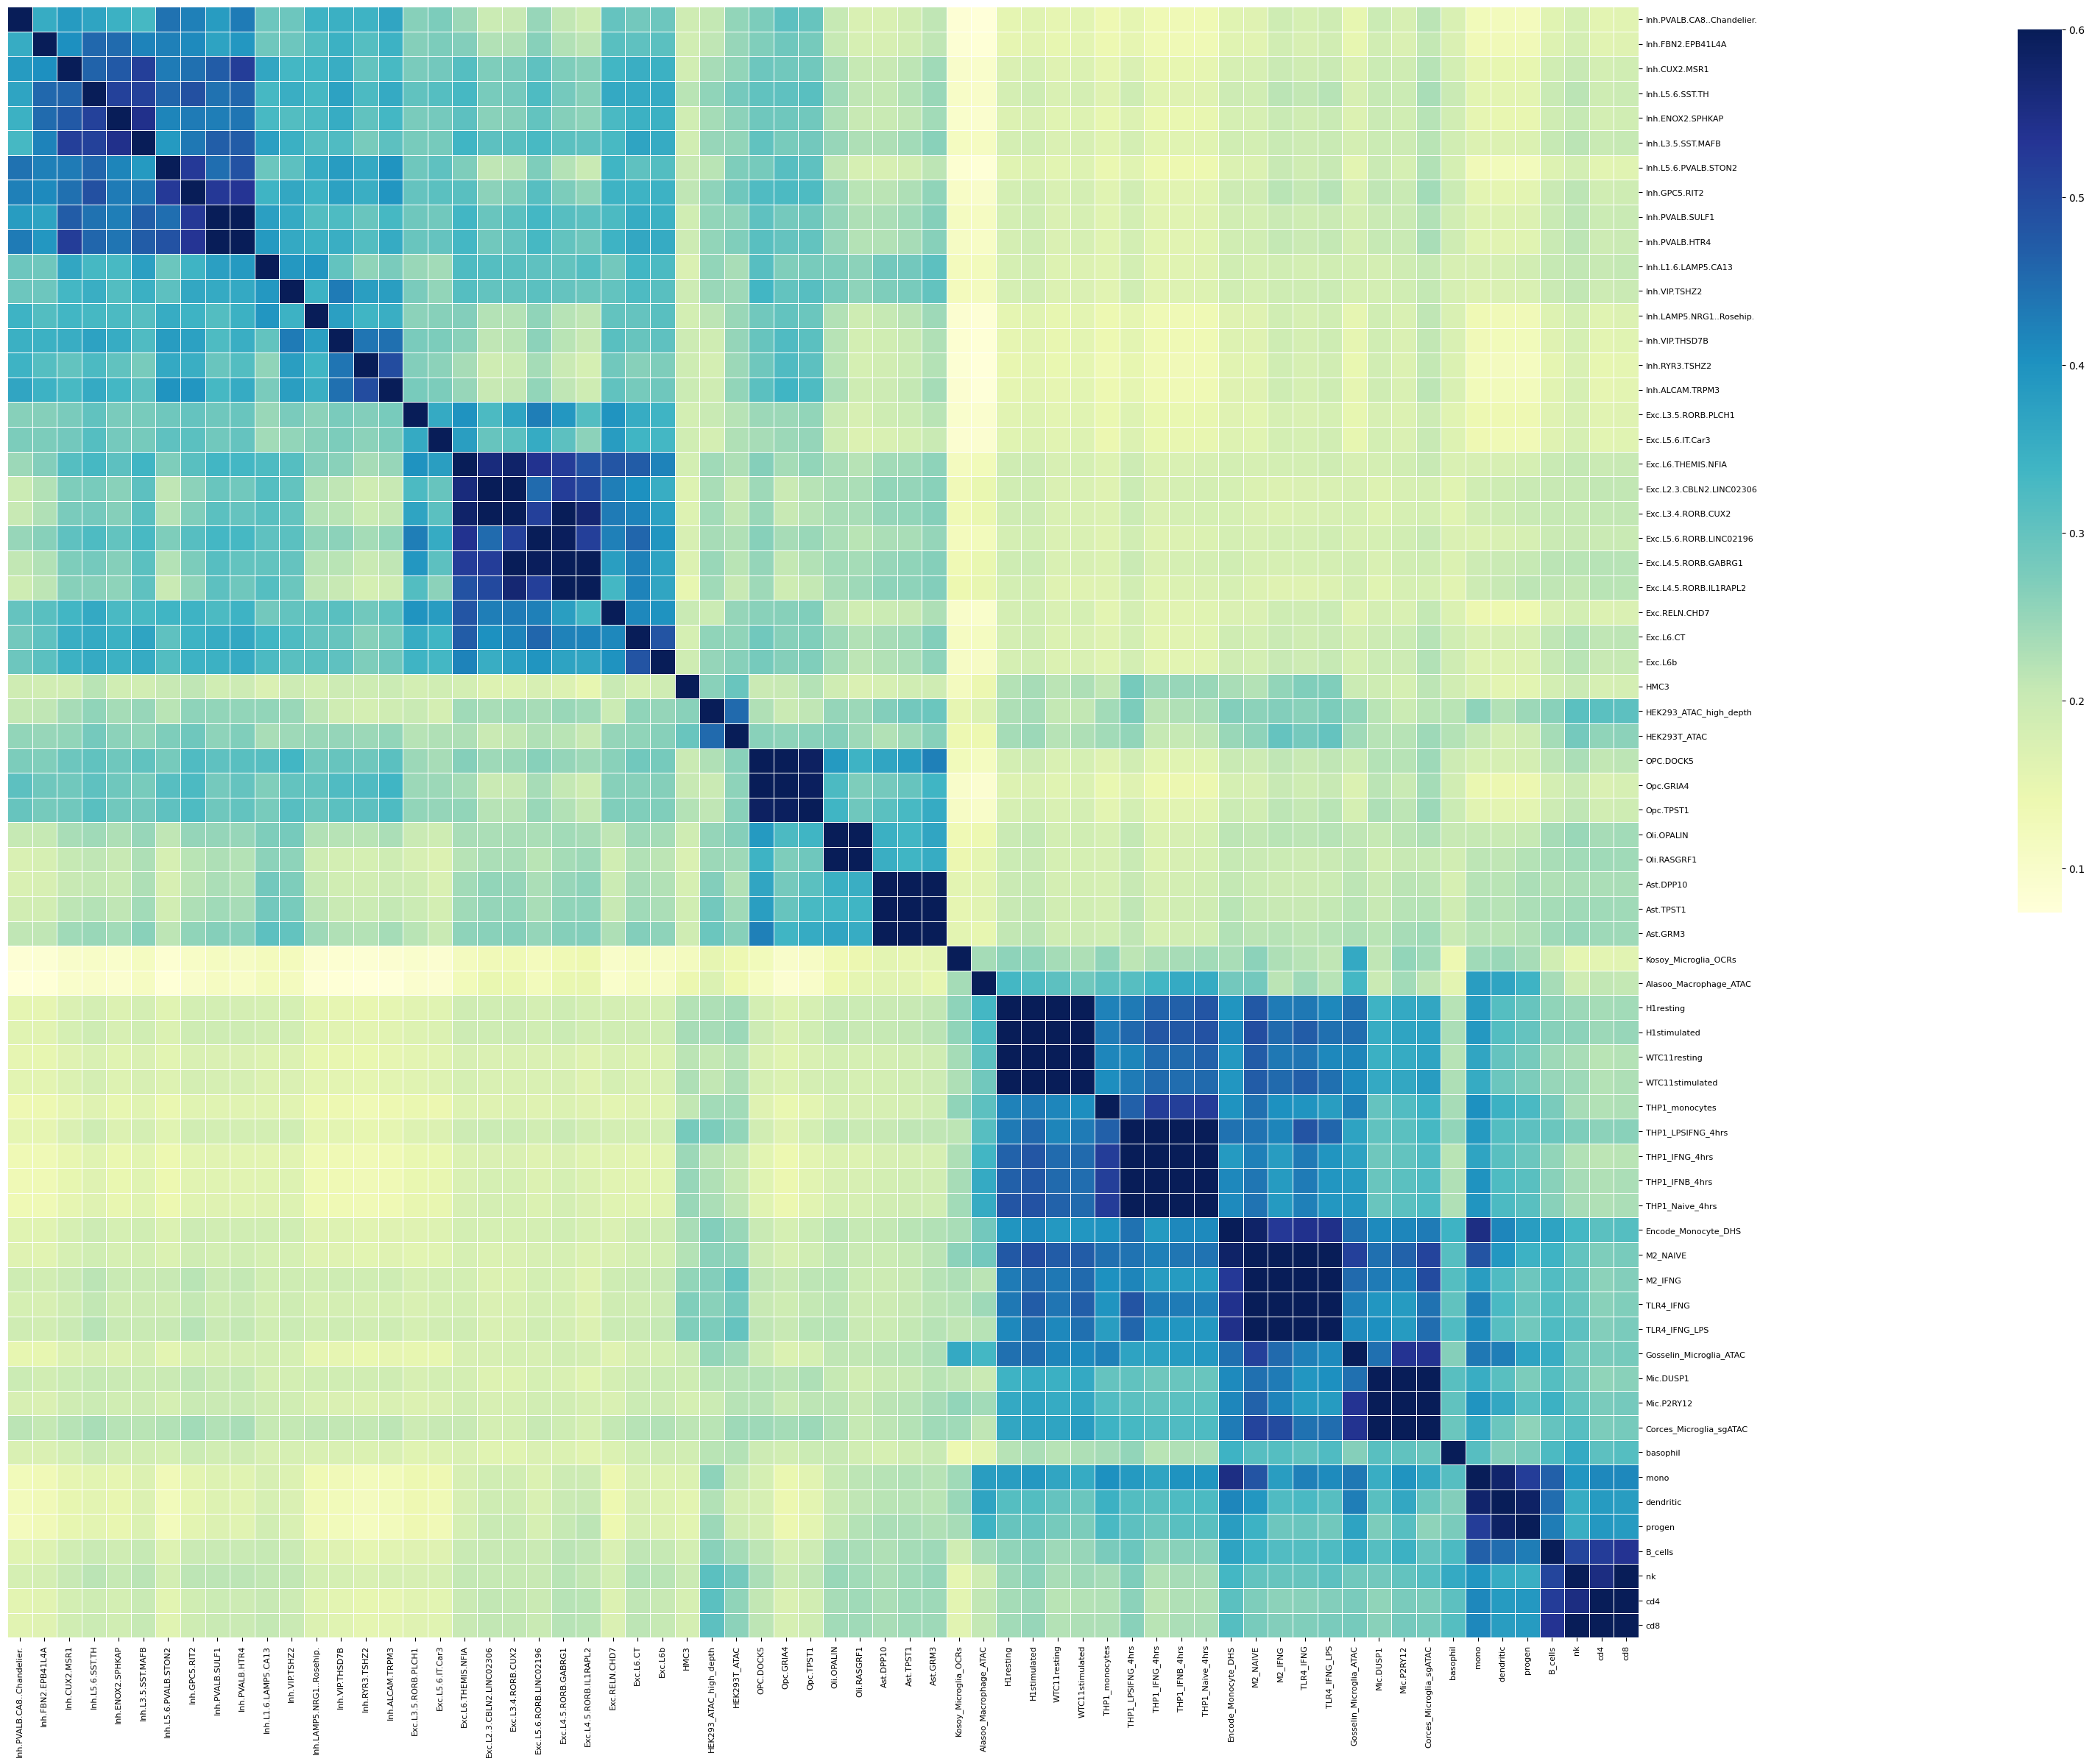

Row order after clustering: [40, 33, 31, 37, 27, 34, 24, 32, 39, 41, 23, 35, 28, 46, 44, 47, 29, 45, 22, 25, 42, 20, 36, 38, 52, 17, 18, 2, 43, 61, 53, 48, 50, 49, 51, 30, 16, 19, 3, 59, 55, 56, 57, 58, 10, 9, 8, 7, 11, 0, 5, 4, 12, 13, 1, 15, 54, 60, 64, 6, 63, 65, 62, 14, 21, 26]
Column order after clustering: [40, 33, 31, 37, 27, 34, 24, 32, 39, 41, 23, 35, 28, 46, 44, 47, 29, 45, 22, 25, 42, 20, 36, 38, 52, 17, 18, 2, 43, 61, 53, 48, 50, 49, 51, 30, 16, 19, 3, 59, 55, 56, 57, 58, 10, 9, 8, 7, 11, 0, 5, 4, 12, 13, 1, 15, 54, 60, 64, 6, 63, 65, 62, 14, 21, 26]


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your Jaccard index dataframe
jaccard_df = pd.read_csv('/media/zihengc/T7/atac/jaccard_index/jaccard_df_20240907.csv', index_col=0)
jaccard_df.columns = jaccard_df.columns.str.replace('.idr.optimal_peak.narrowPeak', '', regex=False).str.replace('.peak.annotation.txt', '', regex=False).str.replace('.narrowPeak', '', regex=False).str.replace('.txt', '', regex=False).str.replace('.bed', '', regex=False).str.replace('_hg38', '', regex=False).str.replace('.idr.optimal', '', regex=False).str.replace('.idr.conservative_peak', '', regex=False)
jaccard_df.index = jaccard_df.index.str.replace('.idr.optimal_peak.narrowPeak', '', regex=False).str.replace('.peak.annotation.txt', '', regex=False).str.replace('.narrowPeak', '', regex=False).str.replace('.txt', '', regex=False).str.replace('.bed', '', regex=False).str.replace('_hg38', '', regex=False).str.replace('.idr.optimal', '', regex=False).str.replace('.idr.conservative_peak', '', regex=False)

# Define the list of samples to exclude
exclude_list = [
]
# Drop the excluded samples from rows and columns
jaccard_df = jaccard_df.drop(exclude_list).drop(exclude_list, axis=1)
# Create the clustermap
g = sns.clustermap(jaccard_df, cmap="YlGnBu", annot=False, fmt=".2f", linewidths=.5,
                   cbar_pos=(0.05, 0.85, 0.05, 0.1), vmax=0.6, figsize=(30, 30), method="average")

# Adjust the size and visibility of the color bar
g.cax.set_visible(True)
g.cax.set_position([1.1, 0.4, 0.02, 0.4])
# Optional: Hide the dendrograms
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8)
# Adjust layout and display the plot
plt.tight_layout()
plt.show()
# Retrieve and print the order of the rows and columns after clustering
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
print("Row order after clustering:", row_order)
print("Column order after clustering:", col_order)

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
df_peak = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv',index_col=0)  # replace with your DataFrame
df_peak = df_peak.drop_duplicates('RSID')
df_peakonly = df_peak.iloc[:, 76:].apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)).drop(['GC_content', 'distance_to_tss'], axis=1)
df_peakonly.columns = df_peakonly.columns.str.replace('.idr.optimal_peak.narrowPeak', '', regex=False).str.replace('.peak.annotation.txt', '', regex=False).str.replace('.narrowPeak', '', regex=False).str.replace('.txt', '', regex=False).str.replace('.bed', '', regex=False).str.replace('_hg38', '', regex=False).str.replace('.idr.optimal', '', regex=False).str.replace('.idr.conservative_peak', '', regex=False)
order = jaccard_df.iloc[col_order].index#.str.replace('.idr.optimal_peak', '', regex=False).str.replace('.peak.annotation', '', regex=False).str.replace('.idr.conservative_peak', '', regex=False)

df_peakonly = df_peakonly.loc[:,order]
c1 = order[0:27]
c2 = order[27:30]
c3 =order[30:38]
c4 = order[38:]
clusters2_new = np.array([1]*len(c1)+[2]*len(c2)+[3]*len(c3)+[4]*len(c4))

# Perform K-means clustering on rows
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_peakonly)
df_peakonly['Cluster'] = clusters
df_peakonly = df_peakonly.sort_values('Cluster')
clusters_new = df_peakonly['Cluster']
df_peakonly = df_peakonly.drop('Cluster', axis=1)

# Create a colormap for the row clusters
lut_row = dict(zip(set(clusters_new ), sns.color_palette("Set1", n_colors=len(set(clusters_new)))))
row_colors = pd.Series(clusters_new , index=df_peakonly.index).map(lut_row)

lut_col = dict(zip(set(clusters2_new), sns.color_palette("pastel", n_colors=len(set(clusters2_new)))))
col_colors = pd.Series(clusters2_new, index=df_peakonly.columns).map(lut_col)

# Create the clustermap
g = sns.clustermap(df_peakonly, 
                   cmap="vlag", 
                   row_colors=row_colors,  # Row colors based on row clusters
                   #col_colors=col_colors,  # Column colors based on column clusters
                   figsize=(80, 170),
                   cbar_pos=None,
                   row_cluster=False,
                   col_cluster=False,
                   yticklabels=False)
# Apply tight layout
plt.tight_layout()  # Will ensure that the layout fits better without overlapping

# Identify blue blocks (value 0) and apply custom coloring
for i in range(df_peakonly.shape[0]):
    for j in range(df_peakonly.shape[1]):
        if df_peakonly.iloc[i, j] == 0:  # Check for value 0
            g.ax_heatmap.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=col_colors[df_peakonly.columns[j]]))

# Remove the dendrograms
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
# Save the clustermap
g.savefig("SNPs_clustermap_byATAC_20240911.pdf", dpi=300)


In [19]:


df_peakonly_new = df_peakonly.copy()
df_peakonly_new.loc['Cluster2',:] = clusters2_new
df_peakonly_new['Cluster'] = clusters_new

df_peakonly_new.to_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_ATAC_clustered_20240905.csv')

snp_immune = df_peakonly_new[df_peakonly_new['Cluster']==0]#immune
snp_ubiquitous = df_peakonly_new[df_peakonly_new['Cluster']==1]
snp_other = df_peakonly_new[df_peakonly_new['Cluster']==2]
df_peak_new = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv',index_col=0)  # replace with your DataFrame
df_peak.loc[snp_other.index,'SNP_Function'] = "Immune"
df_peak.loc[snp_ubiquitous.index,'SNP_Function'] = "Ubiquitous"
df_peak.loc[snp_immune.index,'SNP_Function'] ="Low ATAC" 

df_peak = pd.merge(df_peak_new.reset_index(),df_peak[['SNP_Function','RSID']],left_on='RSID',right_on='RSID').set_index('index') 

df_peak.to_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_20240911.csv') 


In [20]:
df_peak.drop_duplicates("RSID").groupby("SNP_Function").count()

,Type,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,r2,D',is_query_snp,...,WTC11stimulated.idr.optimal_peak.narrowPeak,Alasoo_Macrophage_ATAC_hg38.bed,Corces_Microglia_sgATAC_hg38.idr.optimal.narrowPeak,HEK293T_ATAC.idr.conservative_peak.narrowPeak,B_cells_hg38.bed,dendritic_hg38.bed,basophil_hg38.bed,progen_hg38.bed,GC_content,distance_to_tss
SNP_Function,,,,,,,,,,,,,,,,,,,,,
Immune,185,185,185,185,185,185,185,170,170,170,...,185,185,185,185,185,185,185,185,185,185
Low ATAC,337,337,337,337,337,337,337,301,301,301,...,337,337,337,337,337,337,337,337,337,337
Ubiquitous,77,77,77,77,77,77,77,56,56,56,...,77,77,77,77,77,77,77,77,77,77


In [67]:
#cluster snps
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')  # The number of clusters and linkage method can be adjusted
clusters = agglo.fit_predict(df_peakonly)

df_peakonly['Cluster'] = clusters
df_peakonly = df_peakonly.sort_values('Cluster')
clusters_new = df_peakonly['Cluster']
df_peakonly = df_peakonly.drop('Cluster', axis=1)

# Annotate promoter peaks

In [23]:
import pandas as pd
def annotate_promoter_10kbTSS(gtf_file,output):
    chromosome =[]
    for i in range(1,23):
        chromosome.append(str(i))
    chromosome.append("X")
    chromosome.append("Y")

    # Read the GTF file
    # Make sure to adjust the column names and separator based on your GTF format
    gtf_df = pd.read_csv(gtf_file, sep='\t', comment='#', header=None)
    gtf_df.columns = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']

    gtf_df = gtf_df[gtf_df['seqname'].astype("str").isin(chromosome)]

    # Filter for genes (or modify to filter for specific features representing TSS)
    tss_df = gtf_df[gtf_df['feature'] == 'gene']

    # Define a function to adjust TSS based on strand
    def adjust_tss(row, window=10000):
        if row['strand'] == '+':
            start = max(0, row['start'] - window)
            end = row['start'] + window
        else:
            start = max(0, row['end'] - window)
            end = row['end'] + window
        return pd.Series([start, end])

    # Apply the function to calculate the adjusted TSS intervals
    tss_df[['tss_start', 'tss_end']] = tss_df.apply(lambda row: adjust_tss(row), axis=1)

    # Create a BED file
    bed_df = tss_df[['seqname', 'tss_start', 'tss_end']]
    bed_df['seqname'] ='chr'+bed_df['seqname'].astype("str")
    bed_df.to_csv(output, sep='\t', header=False, index=False)

# Replace this with the path to your GTF file
gtf_file = '/media/zihengc/T7/resources/Ensembl_genome_annotation/Homo_sapiens.GRCh38.111.gtf.gz'
output = 'indexing/ensembl_tss_10kbintervals.bed'
annotate_promoter_10kbTSS(gtf_file,output)

In [28]:
def annotate_promoter_10kbTSS(gtf_file,output):
    chromosome =[]
    for i in range(1,23):
        chromosome.append("chr"+str(i))
    chromosome.append("chrX")
    chromosome.append("chrY")

    # Read the GTF file
    # Make sure to adjust the column names and separator based on your GTF format
    gtf_df = pd.read_csv(gtf_file, sep='\t', comment='#', header=None)
    gtf_df.columns = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']

    gtf_df = gtf_df[gtf_df['seqname'].astype("str").isin(chromosome)]

    # Filter for genes (or modify to filter for specific features representing TSS)
    tss_df = gtf_df[gtf_df['feature'] == 'gene']

    # Define a function to adjust TSS based on strand
    def adjust_tss(row, window=10000):
        if row['strand'] == '+':
            start = max(0, row['start'] - window)
            end = row['start'] + window
        else:
            start = max(0, row['end'] - window)
            end = row['end'] + window
        return pd.Series([start, end])

    # Apply the function to calculate the adjusted TSS intervals
    tss_df[['tss_start', 'tss_end']] = tss_df.apply(lambda row: adjust_tss(row), axis=1)

    # Create a BED file
    bed_df = tss_df[['seqname', 'tss_start', 'tss_end']]

    bed_df.to_csv(output, sep='\t', header=False, index=False)

# Replace this with the path to your GTF file
gtf_file = '/media/zihengc/T7/resources/Gencode_genome_annotation/gencode.v45.annotation.gtf.gz' 
output = 'indexing/gencode_tss_10kbintervals.bed'
annotate_promoter_10kbTSS(gtf_file,output)

/tmp/ipykernel_11811/911757591.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tss_df[['tss_start', 'tss_end']] = tss_df.apply(lambda row: adjust_tss(row), axis=1)
/tmp/ipykernel_11811/911757591.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tss_df[['tss_start', 'tss_end']] = tss_df.apply(lambda row: adjust_tss(row), axis=1)


       chr      start        end  distance_to_tss
0    chr19   42423524   42423525             1547
1    chr16   89532542   89532543           -28082
2    chr16    2205198    2205199             -950
3     chr8   41661790   41661791             -799
4    chr19    2720849    2720850              523
..     ...        ...        ...              ...
850   chr6  150862035  150862036             3644
851   chr9  124221903  124221904            35703
852  chr19    1999195    1999196             4386
853  chr11   60156035   60156036             4787
854  chr17   63445344   63445345             1010

[855 rows x 4 columns]
